# nb08 — Multilayer pathway states

## Scientific question
Which selected programs have concordant RNA, accessibility and measured protein
evidence, and which have inconsistent or missing support?

## Analysis strategy
Summarize saved nb04–07 tables for the same donor and selected cell-type/pathway
panel. Pairing is retained only within each capture. RNA enrichment, relative
population activity and within-type associations are different measurements and
are displayed separately. No combined activation score or forced binary label.

Copy this notebook plus `src/multimodal_summary.py` and `src/multimodal_plots.py`
to your existing Drive project. Earlier shared modules and outputs must remain
available. No raw h5ad reads or reruns of nb04–07 are required.

In [1]:
from pathlib import Path
import sys
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics-relationship-modeling')
except ImportError:
    BASE_PATH = Path.cwd().resolve()
    if not (BASE_PATH / 'src').is_dir():
        BASE_PATH = BASE_PATH.parent
sys.path.insert(0, str(BASE_PATH))
import pandas as pd
from IPython.display import display, Image
from src.multimodal_summary import run_summary
OUTPUT_ROOT = BASE_PATH / 'results/single_donor'
RELATIVE_PROTEIN_THRESHOLD = 0.5
summary, proteins, provenance = run_summary(OUTPUT_ROOT, threshold=RELATIVE_PROTEIN_THRESHOLD)
print('Donor:', provenance['donor'])
print('Saved results:', OUTPUT_ROOT / 'multilayer')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Donor: 15078
Saved results: /content/drive/MyDrive/multiomics-relationship-modeling/results/single_donor/multilayer


## Program evidence across captures
RNA NES/q-values describe cell-type enrichment in each capture. Multiome RNA/ATAC
means use the same covered genes, each standardized within its own layer. Protein
coverage is the fraction of original GMT genes with directly mapped ADTs, not the
fraction of pathway function measured. Missing protein coverage cannot be low activity.

In [2]:
with pd.option_context('display.max_columns', None, 'display.max_colwidth', 100):
    display(summary[['cell_type', 'pathway', 'NES_cite', 'q_value_cite', 'NES_multiome', 'q_value_multiome',
                     'activity_rna_mean', 'activity_atac_mean', 'activity_state', 'atac_coverage',
                     'atac_adjusted_pearson', 'atac_site_values', 'protein_n_direct_genes',
                     'protein_direct_gene_coverage', 'protein_interpretation']])

,cell_type,pathway,NES_cite,q_value_cite,NES_multiome,q_value_multiome,activity_rna_mean,activity_atac_mean,activity_state,atac_coverage,atac_adjusted_pearson,atac_site_values,protein_n_direct_genes,protein_direct_gene_coverage,protein_interpretation
0,CD14 monocytes,Inflammatory Response,1.886618,0.010355,1.868768,0.012084,0.295613,0.207125,intermediate / mixed,0.630000,0.336784,site1: 0.455; site2: 0.197; site4: 0.344,14,0.070000,"Positive adjusted module association in all testable sites: CD14, CD54, CD82, CD88; measured sub..."
1,CD14 monocytes,TNF-alpha Signaling via NF-kB,2.042902,0.010355,1.954407,0.012084,0.291382,0.157299,intermediate / mixed,0.795000,0.477397,site1: 0.587; site2: 0.315; site4: 0.481,6,0.030000,"Positive adjusted module association in all testable sites: CD44, CD54; measured subset only; si..."
2,CD16 monocytes,Interferon Alpha Response,1.947899,0.008788,1.954336,0.009088,0.189353,0.046514,intermediate / mixed,0.865979,0.117519,site1: 0.300; site2: 0.124; site4: 0.049,3,0.030928,No direct ADT has positive adjusted module association in all testable sites; measured subset on...
3,Lymphoid progenitors,E2F Targets,1.803852,0.009829,1.909167,0.012861,0.067158,-0.037062,intermediate / mixed,0.975000,0.048267,site1: 0.243; site2: -0.136; site4: 0.105,1,0.005000,No direct ADT has positive adjusted module association in all testable sites; measured subset on...
4,MK/E progenitors,Myc Targets V1,2.065594,0.008886,2.036687,0.012462,0.290063,-0.032376,intermediate / mixed,0.980000,0.010419,site1: -0.077; site2: untested; site4: -0.040,0,0.000000,Protein unmeasured; no protein-state or decoupling conclusion


## Protein states and site sensitivity
Show each ADT independently. Its mean z-score is relative to the donor's equal-type
reference: high >= +0.5, low <= -0.5, otherwise intermediate. These are exploratory
cutoffs, not significance or absolute protein activity. CITE RNA module means have
different coverage from nb06 and are not directly comparable numerical effect sizes.

Site sign consistency has no minimum effect threshold and is **not** a statistical
support label: inspect magnitudes. Untested sites are excluded from sign counts and
remain visible. Same-gene and module associations answer different questions.

,cell_type,pathway,adt,evidence_type,rna_module_mean,adt_mean_z,relative_protein_state,pearson,adjusted_pearson,same_gene_adjusted_pearson,n_testable_sites,n_sites,site_values
0,CD14 monocytes,Inflammatory Response,CD155,direct molecular match,0.282337,0.421134,intermediate,0.041410,-0.098477,-0.010440,4,4,site1: -0.243; site2: -0.084; site3: -0.061; s...
1,CD14 monocytes,Inflammatory Response,CD48,direct molecular match,0.282337,0.438281,intermediate,0.556225,0.008057,-0.006693,4,4,site1: -0.079; site2: 0.024; site3: 0.025; sit...
2,CD14 monocytes,Inflammatory Response,CD40,direct molecular match,0.282337,-0.448036,intermediate,-0.175134,0.008637,0.011360,4,4,site1: 0.093; site2: 0.013; site3: -0.046; sit...
3,CD14 monocytes,Inflammatory Response,CD14,direct molecular match,0.282337,1.759471,high,0.435477,0.279363,0.168454,4,4,site1: 0.488; site2: 0.228; site3: 0.213; site...
4,CD14 monocytes,Inflammatory Response,CD69,direct molecular match,0.282337,-0.225979,intermediate,-0.056503,0.022750,-0.001738,4,4,site1: 0.109; site2: 0.022; site3: -0.005; sit...
5,CD14 monocytes,Inflammatory Response,CD62L,direct molecular match,0.282337,0.549644,high,0.068610,-0.154082,0.194089,4,4,site1: -0.256; site2: -0.152; site3: -0.099; s...
6,CD14 monocytes,Inflammatory Response,CD42b,direct molecular match,0.282337,0.100094,intermediate,-0.053413,0.022765,0.018470,4,4,site1: 0.074; site2: 0.047; site3: -0.028; sit...
7,CD14 monocytes,Inflammatory Response,CD54,direct molecular match,0.282337,0.359596,intermediate,0.492963,0.170560,0.038127,4,4,site1: 0.285; site2: 0.111; site3: 0.180; site...
8,CD14 monocytes,Inflammatory Response,CD122,direct molecular match,0.282337,-0.618836,low,-0.316157,-0.000458,0.024655,4,4,site1: 0.038; site2: -0.000; site3: -0.033; si...
9,CD14 monocytes,Inflammatory Response,CD137,direct molecular match,0.282337,-0.411332,intermediate,-0.387142,-0.004271,0.018179,4,4,site1: 0.043; site2: 0.030; site3: -0.105; sit...


,cell_type,pathway,adt,n_sites,n_testable_sites,n_positive_sites,n_negative_sites,site_adjusted_min,site_adjusted_max,site_values
0,CD14 monocytes,Inflammatory Response,CD155,4,4,1,3,-0.036781,0.019125,site1: -0.037; site2: -0.012; site3: -0.007; s...
1,CD14 monocytes,Inflammatory Response,CD48,4,4,2,2,-0.081322,0.007632,site1: -0.079; site2: 0.005; site3: 0.008; sit...
2,CD14 monocytes,Inflammatory Response,CD40,4,4,3,1,-0.033151,0.061542,site1: 0.031; site2: 0.035; site3: -0.033; sit...
3,CD14 monocytes,Inflammatory Response,CD14,4,4,4,0,0.118488,0.399196,site1: 0.399; site2: 0.118; site3: 0.164; site...
4,CD14 monocytes,Inflammatory Response,CD69,4,4,2,2,-0.013220,0.022756,site1: -0.013; site2: 0.023; site3: -0.013; si...
5,CD14 monocytes,Inflammatory Response,CD62L,4,4,4,0,0.149180,0.309341,site1: 0.226; site2: 0.216; site3: 0.149; site...
6,CD14 monocytes,Inflammatory Response,CD42b,4,3,2,1,-0.019444,0.028869,site1: -0.019; site2: 0.029; site3: untested; ...
7,CD14 monocytes,Inflammatory Response,CD54,4,4,4,0,0.004413,0.143294,site1: 0.143; site2: 0.004; site3: 0.027; site...
8,CD14 monocytes,Inflammatory Response,CD122,4,3,2,1,-0.052074,0.036051,site1: -0.052; site2: 0.035; site3: 0.036; sit...
9,CD14 monocytes,Inflammatory Response,CD137,4,4,4,0,0.004090,0.054142,site1: 0.037; site2: 0.004; site3: 0.034; site...


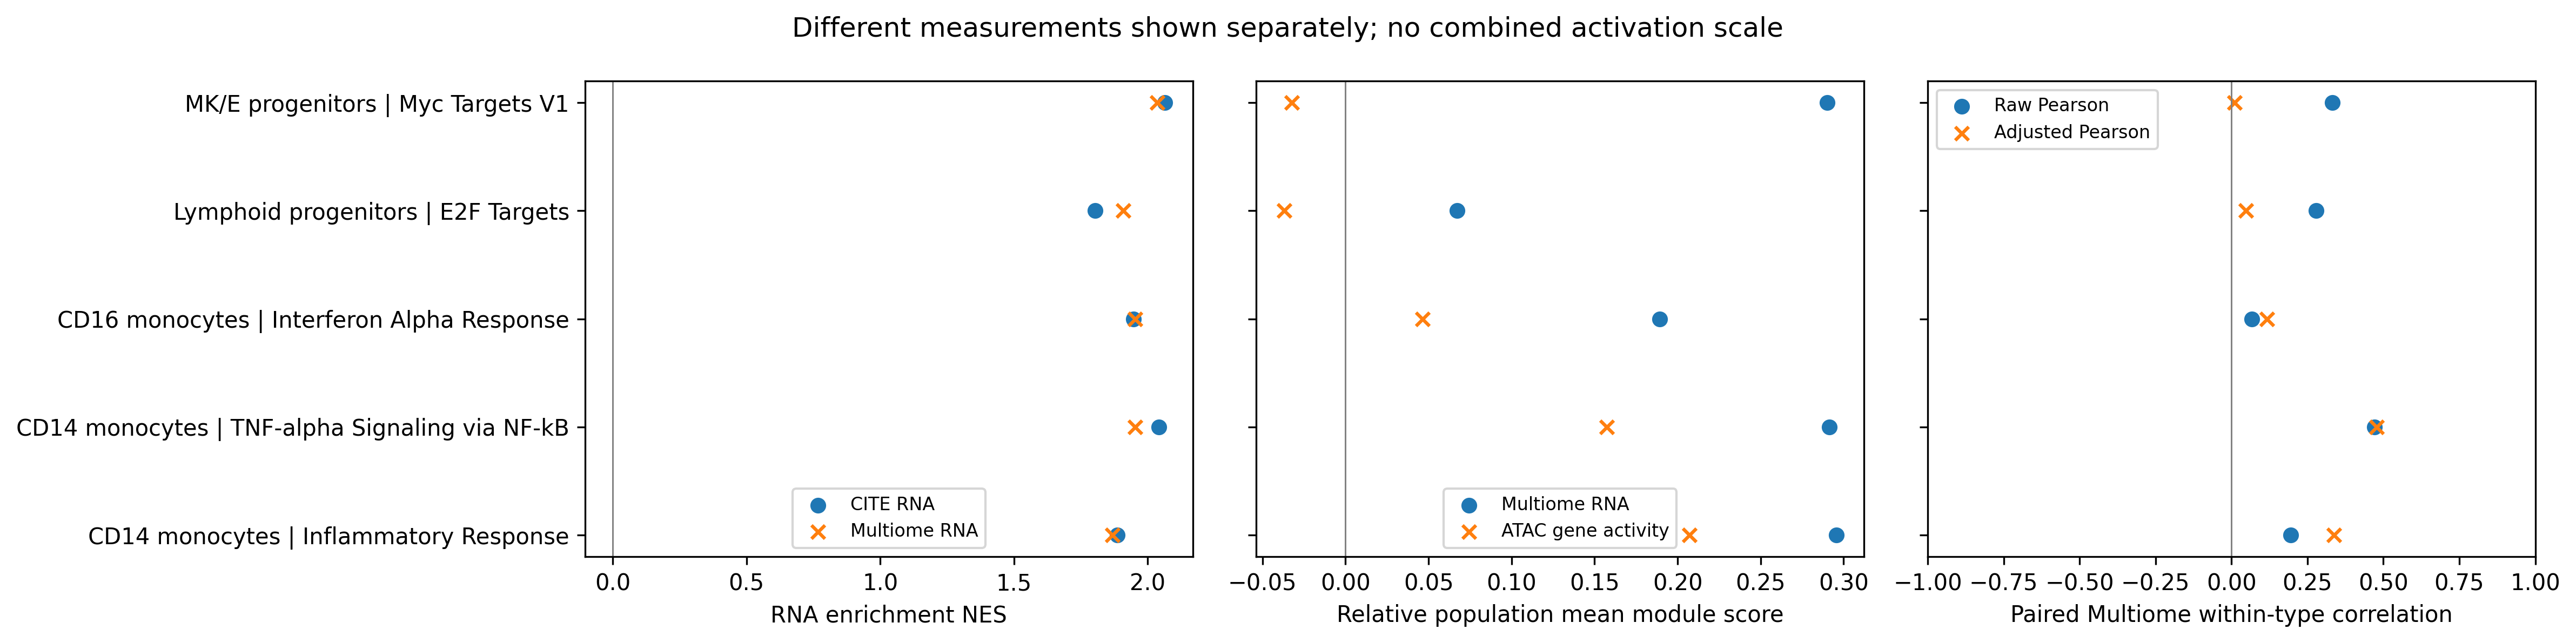

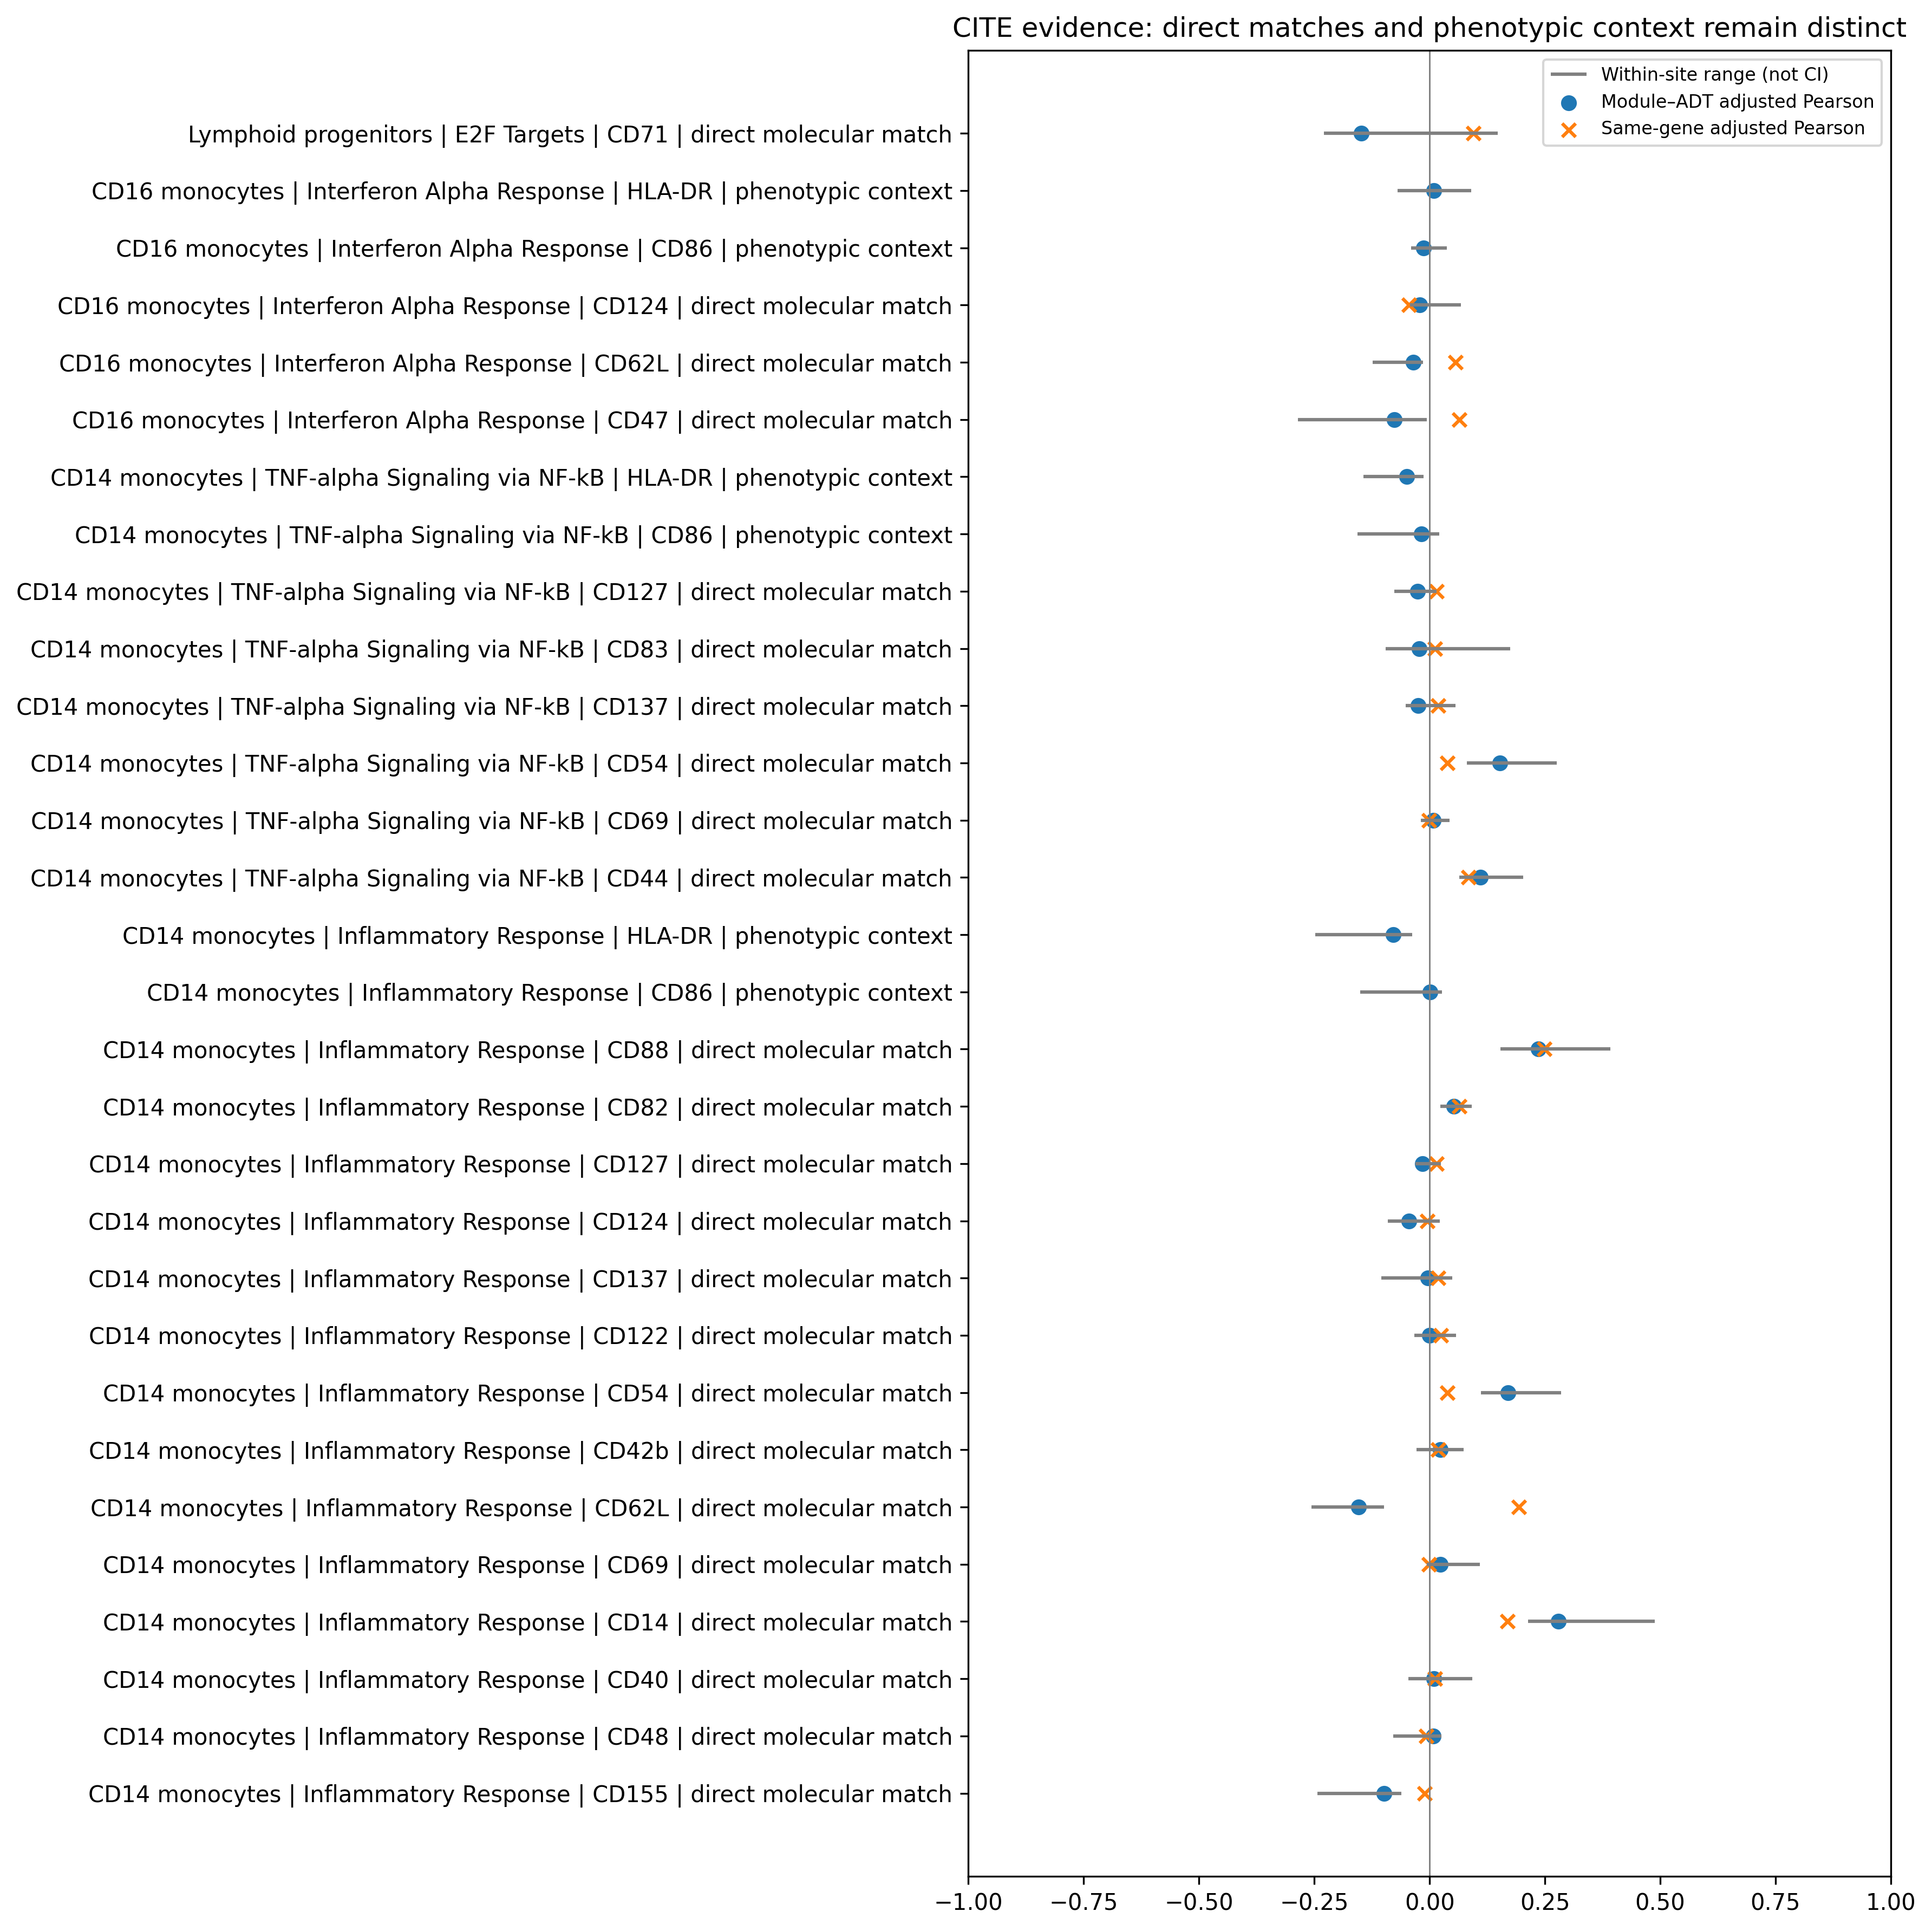

In [3]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(proteins[['cell_type', 'pathway', 'adt', 'evidence_type', 'rna_module_mean',
                      'adt_mean_z', 'relative_protein_state', 'pearson', 'adjusted_pearson',
                      'same_gene_adjusted_pearson', 'n_testable_sites', 'n_sites', 'site_values']])
    display(pd.read_csv(OUTPUT_ROOT / 'multilayer/same_gene_site_sensitivity.csv'))
for name in provenance['figures']:
    display(Image(filename=str(OUTPUT_ROOT / 'multilayer/figures' / name)))

## State-threshold sensitivity and interpretation
Keep nb06's intermediate states. Elevated RNA and ATAC means do not imply positive
within-type covariation, and positive covariation does not imply elevated means.
High accessibility with low RNA is at most a potentially permissive relative state;
temporal priming cannot be established. RNA/protein disagreement is a candidate
observation subject to coverage, normalization and confounding, not proven decoupling.

In [4]:
display(pd.read_csv(OUTPUT_ROOT / 'multilayer/atac_state_sensitivity.csv'))
for threshold in [0.25, 0.5, 0.75]:
    view = proteins[['cell_type', 'pathway', 'adt', 'adt_mean_z']].copy()
    view['threshold'] = threshold
    view['state'] = view.adt_mean_z.map(lambda x: 'unmeasured/constant' if pd.isna(x) else 'high' if x >= threshold else 'low' if x <= -threshold else 'intermediate')
    display(view)

,program_id,cell_type,pathway,threshold,n_cells,state
0,P01,CD14 monocytes,Inflammatory Response,0.25,3243,intermediate / mixed
1,P01,CD14 monocytes,Inflammatory Response,0.50,3243,intermediate / mixed
2,P01,CD14 monocytes,Inflammatory Response,0.75,3243,intermediate / mixed
3,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,0.25,3243,intermediate / mixed
4,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,0.50,3243,intermediate / mixed
5,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,0.75,3243,intermediate / mixed
6,P03,CD16 monocytes,Interferon Alpha Response,0.25,526,intermediate / mixed
7,P03,CD16 monocytes,Interferon Alpha Response,0.50,526,intermediate / mixed
8,P03,CD16 monocytes,Interferon Alpha Response,0.75,526,intermediate / mixed
9,P04,Lymphoid progenitors,E2F Targets,0.25,452,intermediate / mixed


,cell_type,pathway,adt,adt_mean_z,threshold,state
0,CD14 monocytes,Inflammatory Response,CD155,0.421134,0.25,high
1,CD14 monocytes,Inflammatory Response,CD48,0.438281,0.25,high
2,CD14 monocytes,Inflammatory Response,CD40,-0.448036,0.25,low
3,CD14 monocytes,Inflammatory Response,CD14,1.759471,0.25,high
4,CD14 monocytes,Inflammatory Response,CD69,-0.225979,0.25,intermediate
5,CD14 monocytes,Inflammatory Response,CD62L,0.549644,0.25,high
6,CD14 monocytes,Inflammatory Response,CD42b,0.100094,0.25,intermediate
7,CD14 monocytes,Inflammatory Response,CD54,0.359596,0.25,high
8,CD14 monocytes,Inflammatory Response,CD122,-0.618836,0.25,low
9,CD14 monocytes,Inflammatory Response,CD137,-0.411332,0.25,low


,cell_type,pathway,adt,adt_mean_z,threshold,state
0,CD14 monocytes,Inflammatory Response,CD155,0.421134,0.5,intermediate
1,CD14 monocytes,Inflammatory Response,CD48,0.438281,0.5,intermediate
2,CD14 monocytes,Inflammatory Response,CD40,-0.448036,0.5,intermediate
3,CD14 monocytes,Inflammatory Response,CD14,1.759471,0.5,high
4,CD14 monocytes,Inflammatory Response,CD69,-0.225979,0.5,intermediate
5,CD14 monocytes,Inflammatory Response,CD62L,0.549644,0.5,high
6,CD14 monocytes,Inflammatory Response,CD42b,0.100094,0.5,intermediate
7,CD14 monocytes,Inflammatory Response,CD54,0.359596,0.5,intermediate
8,CD14 monocytes,Inflammatory Response,CD122,-0.618836,0.5,low
9,CD14 monocytes,Inflammatory Response,CD137,-0.411332,0.5,intermediate


,cell_type,pathway,adt,adt_mean_z,threshold,state
0,CD14 monocytes,Inflammatory Response,CD155,0.421134,0.75,intermediate
1,CD14 monocytes,Inflammatory Response,CD48,0.438281,0.75,intermediate
2,CD14 monocytes,Inflammatory Response,CD40,-0.448036,0.75,intermediate
3,CD14 monocytes,Inflammatory Response,CD14,1.759471,0.75,high
4,CD14 monocytes,Inflammatory Response,CD69,-0.225979,0.75,intermediate
5,CD14 monocytes,Inflammatory Response,CD62L,0.549644,0.75,intermediate
6,CD14 monocytes,Inflammatory Response,CD42b,0.100094,0.75,intermediate
7,CD14 monocytes,Inflammatory Response,CD54,0.359596,0.75,intermediate
8,CD14 monocytes,Inflammatory Response,CD122,-0.618836,0.75,intermediate
9,CD14 monocytes,Inflammatory Response,CD137,-0.411332,0.75,intermediate


## Main findings
The reviewed donor-15078 nb07 run identified CD14 inflammatory response as the
clearest measured-subset protein result: CD14/CD88/CD54 module associations remained
positive across four sites, with clearer same-gene agreement for CD14 and CD88.
TNF/NF-kB showed weaker overlapping support. Interferon/E2F lacked consistent positive
adjusted protein support, and Myc had no direct ADT coverage. These are historical
review notes; verify the generated tables if inputs or donor change.

Do not automatically label the five programs coordinated multimodal activation:
population means, paired associations and limited surface measurements must be
considered together. Save the generated evidence tables for review before advancing.

## RNA as a future bridge and unresolved checks
The earlier nb05 review found median mean-expression Pearson about 0.628 and
specificity Spearman about 0.629; its first PC explained 49.8% with capture separation.
These historical results motivate cautious exploration, not readiness for aggressive
integration. Cross-capture site-specific pathway replication and the seven unavailable
nb05 NES values remain unresolved; nb08 does not silently mark them complete.
No latent integration, cell matching, or multi-donor pseudobulk is implemented.

## Limitations
One donor, RNA-selected programs, overlapping gene sets, processed ATAC activity,
limited surface panel and relative scaling constrain conclusions. Depth adjustment
can remove biology; site ranges are not confidence intervals. Older stages lack
hashes of their own output tables, so nb08 records input fingerprints but cannot
prove those tables were never edited. No causal, temporal or donor-generalization
claim follows from this descriptive synthesis.

## Reviewed synthesis — donor 15078

All four code cells completed without errors. All five selected programs have
positive RNA enrichment in both captures (q < 0.013), but downstream support differs.

| Program | Adjusted RNA–ATAC r | Protein evidence | Overall reading |
|---|---:|---|---|
| CD14 inflammatory response | 0.337 | CD14/CD88/CD54 module associations positive across four CITE sites | Clearest measured-subset evidence across layers |
| CD14 TNF/NF-kB | 0.477 | Weaker, consistently positive CD44/CD54 module associations | Strongest RNA–ATAC relationship; limited protein support |
| CD16 interferon-alpha | 0.118 | No consistent positive adjusted direct-ADT module association | RNA enrichment with weak downstream support |
| Lymphoid progenitor E2F | 0.048 | Only CD71 measured; mixed adjusted site directions | Insufficient downstream agreement |
| MK/E progenitor Myc V1 | 0.010 | No direct ADT coverage | Protein evidence unavailable |

Inflammatory CD14 and C5AR1/CD88 show both module association and positive same-gene
RNA–protein agreement across sites. ICAM1/CD54 has weaker same-gene agreement despite
its module-level association. CD82 appears in the sign-consistent automatic summary,
but its adjusted module correlation is only 0.052: sign consistency alone must not
be read as strong evidence. The two CD14 pathways overlap and are not independent
confirmations.

All five RNA–ATAC states remain intermediate/mixed across the tested cutoffs.
Consequently none is established as high across all layers. High relative protein
abundance and correlation with an RNA module are also distinct: CD86 can be high in
a population while showing approximately zero adjusted module association. Negative
or weak associations do not prove decoupling, and absent ADTs never imply inactivity.

The defensible conclusion is that CD14 inflammatory and TNF/NF-kB programs show the
clearest cross-layer associations in this donor, with protein support limited to
small measured subsets. ATAC and protein were measured in different captures, so
this is a population-level synthesis, not a three-modality observation in one cell.

### Remaining validation — planned, not performed here

1. Test cross-capture RNA pathway consistency separately within shared sites; CITE
   site 3 has no matching Multiome site for this donor.
2. Audit the seven unavailable nb05 NES values and assess their impact.
3. Recompute selected RNA–ADT module associations with the matched gene removed
   from the module, to distinguish broader-program association from its own RNA.
4. Update this synthesis after those checks, then assess additional donors before
   pursuing full latent integration or population-level generalization.


## Validation update — supersedes earlier pending-check notes

The three planned checks have now been executed locally. The report below records the results and remaining limits; earlier executed outputs are preserved.

# Completed single-donor validation — donor 15078

Executed locally on 2026-10-07 with `scripts/validate_single_donor.py`. All
manifest-listed input SHA256 fingerprints matched. The copied CITE source matched
the expected size and cell metadata; its SHA256 is recorded in the validation
manifest. Upstream results were not replaced.

## Shared-site RNA pathway consistency

Recomputed cell-type specificity independently in each capture within sites 1, 2
and 4. Within each site, both captures used exactly the same reference cell types,
each with at least 50 cells in both captures, and the frozen 12,000-gene universe.
Reference types can differ between sites. Used 1,000 gene-set permutations and BH
adjustment across all eligible Hallmark sets per target/capture/site, then inspected
the five preselected programs. No cells were paired across captures.

| Program | Testable shared sites | Positive NES and q <= 0.05 in both captures |
|---|---|---|
| CD14 inflammatory response | 1, 2, 4 | 3/3 |
| CD14 TNF/NF-kB | 1, 2, 4 | 3/3 |
| CD16 interferon-alpha | 2, 4 | 2/2 |
| Lymphoid progenitor E2F | 1, 2, 4 | 3/3 |
| MK/E progenitor Myc V1 | None | Untested |

All 11 testable comparisons agreed positively (maximum q approximately 0.021).
CD16 site 1 has only 45 CITE cells. MK/E CITE counts are 14, 43 and 31 in sites
1, 2 and 4; Multiome site 2 also has only 33. These are insufficient groups, not
failed replication. CITE site 3 has no corresponding Multiome site for this donor.
Thus pooled Myc RNA agreement remains without a sufficiently powered site check
under the specified cell-count rule. Site-level agreement is within-donor
consistency, not independent biological replication. No balanced-cell resampling
or donor-level significance is implied by this check.

## Seven unavailable nb05 NES values

All seven had finite negative observed enrichment scores but **zero negative
same-sign null draws among the original 1,000 permutations**. The implemented
same-sign normalization and conditional p-value are consequently undefined.
This is not missing gene coverage or evidence of zero enrichment.

One affected CITE cDC2 heme metabolism. Six affected Multiome G/M progenitors:
allograft rejection, complement, inflammatory response, interferon-gamma response,
TNF/NF-kB and heme metabolism. None is one of our five selected cell-type/pathway
pairs, so this numerical issue does not invalidate their recorded enrichment scores.

An independent 10,000-draw diagnostic yielded only 0–14 same-sign draws per affected
test; G/M interferon-gamma still had zero. Exploratory finite NES estimates based
on 1–14 draws are unstable and must not replace the original missing values or be
used for new significance claims. The cause is established, but reliable normalized
scores for these seven tests remain unavailable. A future change to the null model
or enrichment method must be evaluated systematically, not used selectively to
recover preferred results.

## Leave-one-gene-out protein sensitivity

Reproduced the original nb07 full-module adjusted correlations to tolerance 1e-8
for all three antigens, overall and in each site. Removed only the matched RNA gene
from the 128-gene inflammatory module, leaving 127 genes with the same per-gene
reference standardization. ADT transformation, cells and adjustment stayed fixed.

| ADT | Removed RNA gene | Full adjusted Pearson | Leave-one-out adjusted Pearson | Leave-one-out site range |
|---|---|---:|---:|---:|
| CD14 | CD14 | 0.279 | 0.268 | 0.198–0.475 |
| CD88 | C5AR1 | 0.236 | 0.217 | 0.139–0.364 |
| CD54 | ICAM1 | 0.171 | 0.169 | 0.112–0.278 |

Every association remains positive in all four CITE sites. Inclusion of the matched
gene alone does not explain these module–protein relationships. Other correlated
genes remain in the score, so this does not establish independent mechanistic or
causal evidence. ICAM1/CD54 same-gene agreement remains weak despite its broader
module association.

## Updated interpretation and next step

The CD14 inflammatory program retains the clearest measured-subset support across
RNA, ATAC and protein. TNF/NF-kB has strong RNA–ATAC and weaker protein support.
Interferon and E2F RNA enrichment now show within-site cross-capture consistency,
but this does not strengthen their weak downstream associations automatically.
Myc protein coverage and within-site RNA validation remain unavailable.

The three requested checks have been executed; their coverage and numerical limits
remain explicit. The next substantive step is testing the leading programs across
additional donors with donor-aware summaries, before full latent integration.

Detailed tables and reproducibility metadata are in
`results/single_donor/validation/`: `site_coverage.csv`,
`site_enrichment_all_sets.csv`, `site_pathway_comparison.csv`,
`missing_nes_audit.csv`, `protein_leave_one_gene_out.csv`, and `manifest.json`.
